Chargement des prédictions sauvegardées...
Nombre total d'échantillons: 33037
Colonnes: ['time', 'airport', 'airport_alert_id', 'y', 'proba_xgb', 'proba_lstm', 'last_strike_real', 'alert_end_official']

Calibration: 169 alertes, 15375 échantillons
Validation: 170 alertes, 17662 échantillons

Calibration des modèles...

Recherche du poids optimal α (poids XGB) ...

Résultats pour α à seuil opérationnel = 0.2
    alpha      gain  taux_erreur  nb_anticipees   roc_auc
0    0.00  6.712760     0.141176             64  0.919360
1    0.05  6.712760     0.141176             64  0.920929
2    0.10  6.732564     0.123529             65  0.921065
3    0.15  6.819608     0.111765             68  0.921308
4    0.20  6.824762     0.105882             70  0.921591
5    0.25  6.767619     0.105882             70  0.921892
6    0.30  6.810476     0.105882             70  0.922176
7    0.35  6.613725     0.111765             68  0.922429
8    0.40  6.501961     0.094118             68  0.922616
9    0.45

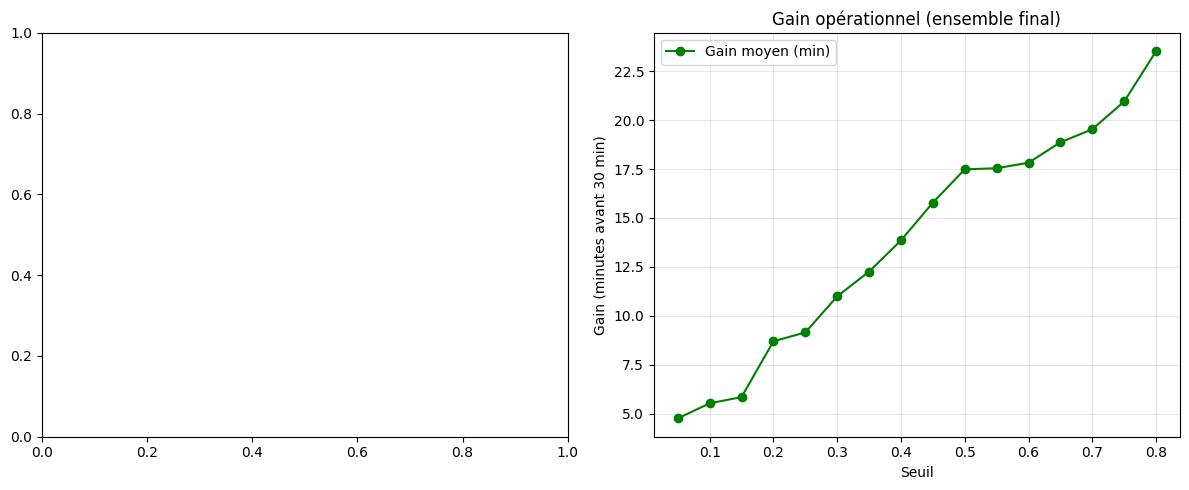

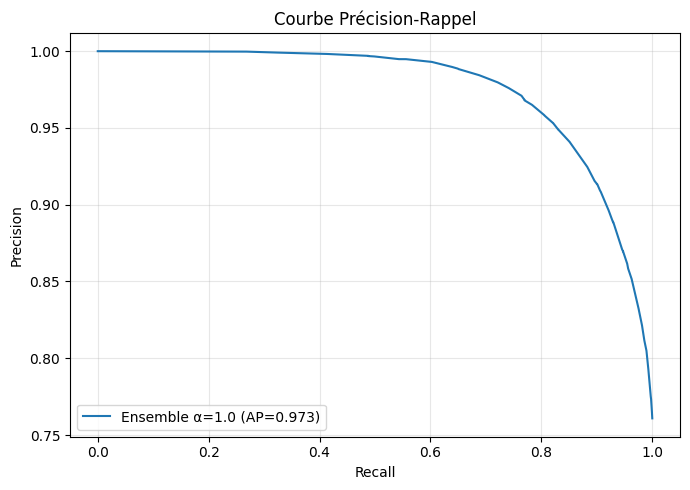


Paramètres sauvegardés : calibrateur_xgb.pkl, calibrateur_lstm.pkl, ensemble_params.pkl


In [ ]:
"""
Ensemble XGBoost + LSTM — Data Battle 2026
==========================================
Combine les probabilités sauvegardées des deux modèles via calibration
isotonique et recherche du meilleur α (poids XGB) sous contrainte
opérationnelle (taux d'erreur ≤ 5%).
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve,
    average_precision_score, classification_report,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split
import joblib

# -----------------------------------------------------------------------------
# 1. Chargement des prédictions
# -----------------------------------------------------------------------------
print("Chargement des prédictions sauvegardées...")
df_xgb = pd.read_csv('val_predictions_xgb.csv', parse_dates=['time', 'last_strike_real', 'alert_end_official'])
df_lstm = pd.read_csv('val_predictions_lstm.csv', parse_dates=['time', 'last_strike_real', 'alert_end_official'])

# Fusion sur les clés, en gardant les colonnes de métadonnées d'un seul côté
# Pour éviter les suffixes, on renomme ou on drop les colonnes redondantes
df_xgb_clean = df_xgb.drop(columns=['last_strike_real', 'alert_end_official'])
df_lstm_clean = df_lstm.drop(columns=['last_strike_real', 'alert_end_official'])

merged = pd.merge(df_xgb_clean, df_lstm_clean,
                  on=['time', 'airport', 'airport_alert_id', 'y'],
                  suffixes=('_xgb', '_lstm'))

# Récupérer les métadonnées depuis un des fichiers (ils sont identiques)
merged['last_strike_real'] = df_xgb['last_strike_real']
merged['alert_end_official'] = df_xgb['alert_end_official']

# Vérifier la cohérence
print(f"Nombre total d'échantillons: {len(merged)}")
print(f"Colonnes: {merged.columns.tolist()}")

y_true = merged['y'].values
proba_xgb = merged['proba_xgb'].values
proba_lstm = merged['proba_lstm'].values
last_strike = merged['last_strike_real'].values
end_official = merged['alert_end_official'].values

# -----------------------------------------------------------------------------
# 2. Séparation en calibration (50% des alertes) et validation (50%)
# -----------------------------------------------------------------------------
# On split par alerte pour ne pas mélanger les échantillons d'une même alerte
alert_ids = merged['airport_alert_id'].unique()
train_ids, val_ids = train_test_split(alert_ids, test_size=0.5, random_state=42)

train_mask = merged['airport_alert_id'].isin(train_ids)
val_mask = merged['airport_alert_id'].isin(val_ids)

X_cal = np.column_stack([proba_xgb[train_mask], proba_lstm[train_mask]])
y_cal = y_true[train_mask]

print(f"\nCalibration: {len(train_ids)} alertes, {X_cal.shape[0]} échantillons")
print(f"Validation: {len(val_ids)} alertes, {val_mask.sum()} échantillons")

# -----------------------------------------------------------------------------
# 3. Calibration isotonique
# -----------------------------------------------------------------------------
def calibrate_isotonic(y_true, y_proba):
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(y_proba, y_true)
    return iso, iso.predict(y_proba)

print("\nCalibration des modèles...")
iso_xgb, _ = calibrate_isotonic(y_cal, X_cal[:, 0])
iso_lstm, _ = calibrate_isotonic(y_cal, X_cal[:, 1])

# Appliquer sur la partie validation
proba_xgb_cal = iso_xgb.predict(proba_xgb[val_mask])
proba_lstm_cal = iso_lstm.predict(proba_lstm[val_mask])
y_val = y_true[val_mask]
last_strike_val = last_strike[val_mask]
end_official_val = end_official[val_mask]

# Créer un DataFrame de validation avec toutes les colonnes nécessaires
val_data = pd.DataFrame({
    'airport_alert_id': merged.loc[val_mask, 'airport_alert_id'].values,
    'time': merged.loc[val_mask, 'time'].values,
    'last_strike_real': last_strike_val,
    'alert_end_official': end_official_val,
    'proba_xgb_cal': proba_xgb_cal,
    'proba_lstm_cal': proba_lstm_cal,
    'y': y_val
})

# -----------------------------------------------------------------------------
# 4. Fonction de calcul du gain et de l'erreur pour un modèle donné
# -----------------------------------------------------------------------------
def compute_gain_erreur(df, col_proba, seuil):
    """
    Calcule gain moyen et taux d'erreur pour un seuil donné.
    df doit contenir les colonnes : airport_alert_id, time, last_strike_real,
    alert_end_official, et la colonne de probabilité.
    """
    gains = []
    erreurs = 0
    total_alertes = 0
    sans_levee = 0

    for alert_id, group in df.groupby('airport_alert_id'):
        total_alertes += 1
        group = group.sort_values('time')
        last_strike_alert = group['last_strike_real'].iloc[0]
        end_official_alert = group['alert_end_official'].iloc[0]

        # Premier instant où proba < seuil
        safe = group[group[col_proba] < seuil]
        if len(safe) == 0:
            sans_levee += 1
            continue

        lift_time = safe.iloc[0]['time']
        if lift_time <= last_strike_alert:
            erreurs += 1
        else:
            gain = (end_official_alert - lift_time).total_seconds() / 60.0
            if gain > 0:
                gains.append(gain)
            else:
                sans_levee += 1

    gain_moyen = np.mean(gains) if gains else 0
    taux_erreur = erreurs / total_alertes if total_alertes > 0 else 0
    return gain_moyen, taux_erreur, len(gains)

# -----------------------------------------------------------------------------
# 5. Recherche du poids optimal α sous contrainte d'erreur ≤ 5%
# -----------------------------------------------------------------------------
print("\nRecherche du poids optimal α (poids XGB) ...")
alphas = np.arange(0.0, 1.05, 0.05)  # pas de 0.05
ERREUR_MAX = 0.05
SEUIL_CIBLE = 0.20  # seuil opérationnel à tester (on pourra aussi balayer)

results = []
for alpha in alphas:
    proba_ens = alpha * val_data['proba_xgb_cal'].values + (1 - alpha) * val_data['proba_lstm_cal'].values
    val_data['proba_ens'] = proba_ens
    gain, err, nb = compute_gain_erreur(val_data, 'proba_ens', SEUIL_CIBLE)
    auc = roc_auc_score(y_val, proba_ens)
    results.append({
        'alpha': alpha,
        'gain': gain,
        'taux_erreur': err,
        'nb_anticipees': nb,
        'roc_auc': auc
    })

df_alphas = pd.DataFrame(results)
print("\nRésultats pour α à seuil opérationnel =", SEUIL_CIBLE)
print(df_alphas.to_string())

# Sélection du meilleur α sous contrainte
valid = df_alphas[df_alphas['taux_erreur'] <= ERREUR_MAX]
if len(valid) > 0:
    best_alpha = valid.loc[valid['gain'].idxmax(), 'alpha']
    print(f"\nMeilleur α (contrainte erreur ≤ {ERREUR_MAX*100:.0f}%) : {best_alpha:.2f}")
else:
    best_alpha = 0.5
    print(f"\nAucun α sous la contrainte, utilisation de α = {best_alpha}")

# -----------------------------------------------------------------------------
# 6. Évaluation finale de l'ensemble avec le meilleur α
# -----------------------------------------------------------------------------
print(f"\nÉvaluation finale avec α = {best_alpha:.2f}")
proba_final = best_alpha * val_data['proba_xgb_cal'].values + (1 - best_alpha) * val_data['proba_lstm_cal'].values
y_pred = (proba_final >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_val, proba_final))
print(classification_report(y_val, y_pred))

# Courbe gain/erreur pour différents seuils
val_data['proba_final'] = proba_final
seuils = np.arange(0.05, 0.81, 0.05)
courbe = []
for s in seuils:
    g, e, nb = compute_gain_erreur(val_data, 'proba_final', s)
    courbe.append({'seuil': s, 'gain': g, 'taux_erreur': e, 'nb_anticipees': nb})
df_courbe = pd.DataFrame(courbe)
print("\nCourbe gain/risque (ensemble final) :")
print(df_courbe.to_string())

# -----------------------------------------------------------------------------
# 7. Graphiques
# -----------------------------------------------------------------------------
# Courbe de calibration avant/après calibration (sur validation)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Calibration curve
# seulemeent les modele combinée 


# Gain vs seuil
ax[1].plot(df_courbe['seuil'], df_courbe['gain'], 'g-o', label='Gain moyen (min)')
ax[1].set_xlabel('Seuil')
ax[1].set_ylabel('Gain (minutes avant 30 min)')
ax[1].set_title('Gain opérationnel (ensemble final)')
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

# Courbe précision-rappel
precision, recall, _ = precision_recall_curve(y_val, proba_final)
ap = average_precision_score(y_val, proba_final)
plt.figure(figsize=(7,5))
plt.plot(recall, precision, label=f'Ensemble α={best_alpha} (AP={ap:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Précision-Rappel')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 8. Sauvegarde des calibrateurs et des paramètres
# -----------------------------------------------------------------------------
joblib.dump(iso_xgb, 'calibrateur_xgb.pkl')
joblib.dump(iso_lstm, 'calibrateur_lstm.pkl')
joblib.dump({'alpha': best_alpha}, 'ensemble_params.pkl')

print("\nParamètres sauvegardés : calibrateur_xgb.pkl, calibrateur_lstm.pkl, ensemble_params.pkl")